In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
import plotly.graph_objects as go


In [2]:
air_quality = fetch_ucirepo(id=360)

In [3]:
df = air_quality.data.features

In [4]:
# Select the specific columns for anomaly detection
features = df[['CO(GT)','C6H6(GT)','NOx(GT)', 'NO2(GT)']]

In [5]:
features

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116
...,...,...,...,...
9352,3.1,13.5,472,190
9353,2.4,11.4,353,179
9354,2.4,12.4,293,175
9355,2.1,9.5,235,156


In [6]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO(GT)    9357 non-null   float64
 1   C6H6(GT)  9357 non-null   float64
 2   NOx(GT)   9357 non-null   int64  
 3   NO2(GT)   9357 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 292.5 KB


In [7]:
n_estimators = 100
contamination = 0.01
sample_size = 256

In [8]:
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples = sample_size, random_state=42)
model.fit(features)

IsolationForest(contamination=0.01, max_samples=256, random_state=42)

In [9]:
anomaly_labels = model.predict(features)

In [10]:
anomaly_labels

array([1, 1, 1, ..., 1, 1, 1], shape=(9357,))

In [11]:
features['anomaly'] = anomaly_labels
features.head()

C:\Users\prabh\AppData\Local\Temp\ipykernel_5908\2357824566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['anomaly'] = anomaly_labels


,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [12]:
features['anomaly'].value_counts()

anomaly
 1    9263
-1      94
Name: count, dtype: int64

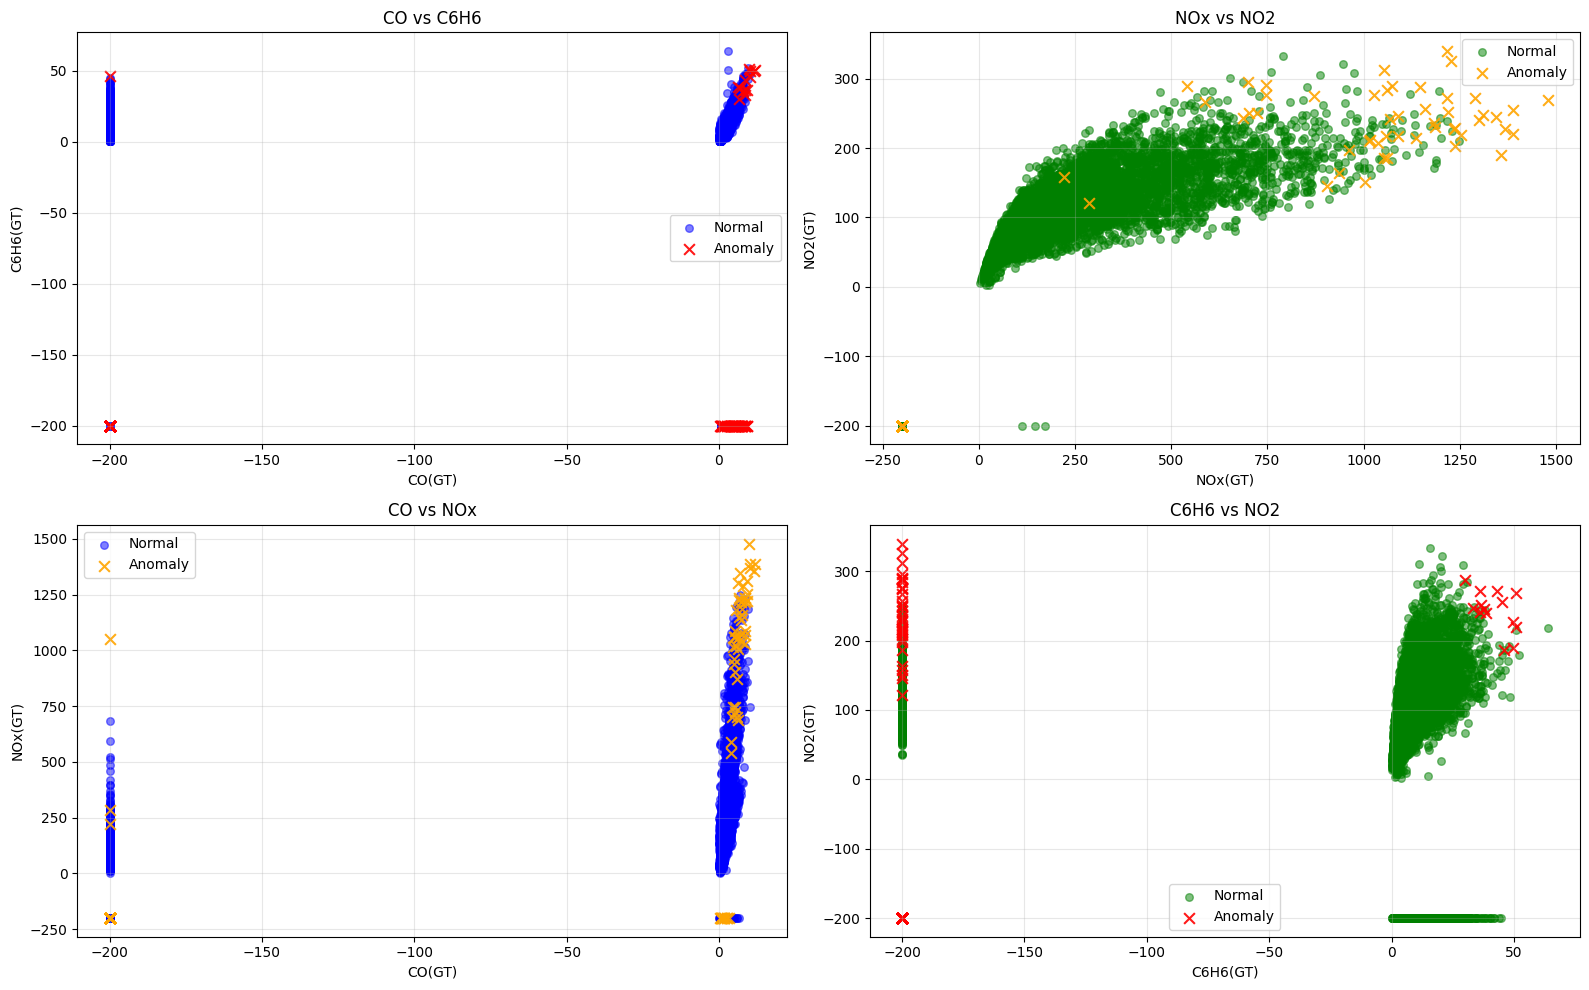

Normal data points: 9263
Anomalies detected: 94


In [13]:
# Visualize anomalies - Multiple feature comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]

# Plot 1: CO vs C6H6
axes[0, 0].scatter(normal['CO(GT)'], normal['C6H6(GT)'],
                   color='blue', label='Normal', alpha=0.5, s=30)
axes[0, 0].scatter(anomaly['CO(GT)'], anomaly['C6H6(GT)'],
                   color='red', label='Anomaly', alpha=0.9, s=60, marker='x')
axes[0, 0].set_xlabel('CO(GT)')
axes[0, 0].set_ylabel('C6H6(GT)')
axes[0, 0].set_title('CO vs C6H6')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: NOx vs NO2
axes[0, 1].scatter(normal['NOx(GT)'], normal['NO2(GT)'],
                   color='green', label='Normal', alpha=0.5, s=30)
axes[0, 1].scatter(anomaly['NOx(GT)'], anomaly['NO2(GT)'],
                   color='orange', label='Anomaly', alpha=0.9, s=60, marker='x')
axes[0, 1].set_xlabel('NOx(GT)')
axes[0, 1].set_ylabel('NO2(GT)')
axes[0, 1].set_title('NOx vs NO2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: CO vs NOx
axes[1, 0].scatter(normal['CO(GT)'], normal['NOx(GT)'],
                   color='blue', label='Normal', alpha=0.5, s=30)
axes[1, 0].scatter(anomaly['CO(GT)'], anomaly['NOx(GT)'],
                   color='orange', label='Anomaly', alpha=0.9, s=60, marker='x')
axes[1, 0].set_xlabel('CO(GT)')
axes[1, 0].set_ylabel('NOx(GT)')
axes[1, 0].set_title('CO vs NOx')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: C6H6 vs NO2
axes[1, 1].scatter(normal['C6H6(GT)'], normal['NO2(GT)'],
                   color='green', label='Normal', alpha=0.5, s=30)
axes[1, 1].scatter(anomaly['C6H6(GT)'], anomaly['NO2(GT)'],
                   color='red', label='Anomaly', alpha=0.9, s=60, marker='x')
axes[1, 1].set_xlabel('C6H6(GT)')
axes[1, 1].set_ylabel('NO2(GT)')
axes[1, 1].set_title('C6H6 vs NO2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Normal data points: {len(normal)}")
print(f"Anomalies detected: {len(anomaly)}")

In [14]:
import plotly.graph_objects as go

# Separate normal and anomaly
normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]

fig = go.Figure()

# Normal points
fig.add_trace(go.Scatter3d(
    x=normal['CO(GT)'],
    y=normal['C6H6(GT)'],
    z=normal['NOx(GT)'],
    mode='markers',
    name='Normal',
    marker=dict(
        size=5,
        color=normal['NO2(GT)'],   # 4th dimension
        colorscale='Blues',
        opacity=0.5,
        colorbar=dict(title='NO2(GT)')
    )
))

# Anomaly points
fig.add_trace(go.Scatter3d(
    x=anomaly['CO(GT)'],
    y=anomaly['C6H6(GT)'],
    z=anomaly['NOx(GT)'],
    mode='markers',
    name='Anomaly',
    marker=dict(
        size=9,                  # size difference instead of symbol
        color=anomaly['NO2(GT)'],
        colorscale='Reds',
        opacity=0.9
    )
))

# Layout
fig.update_layout(
    title='4D Scatter Plot (Color = NO2(GT))',
    scene=dict(
        xaxis_title='CO(GT)',
        yaxis_title='C6H6(GT)',
        zaxis_title='NOx(GT)'
    ),
    width=900,
    height=700
)

fig.show()